In [83]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"./Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df
def save_final_hyperparameters(en, cont, alg, hyper_paramters):
    
    with open("relevant_finals.json", "r+", encoding="utf-8") as f:
        try:
            data = json.load(f)
        except json.JSONDecodeError:
            data = {}
        print(type(data))
        f.seek(0)       
        if cont not in data:
            data[cont] = {}
        if en not in data[cont]:
            data[cont][en] = {}
        data[cont][en][alg] = hyper_paramters
        json.dump(data, f, indent=4)
        f.truncate()
    print(f"Just saved {','.join([cont, en, alg])}")

def get_decided():
    with open("relevant_finals.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        df = pd.json_normalize(data)
    return np.unique(list(map(lambda x: ".".join(x.split(".")[0:3]), df.columns)))


In [171]:
en = "cartpole"
cont = "add_novelty"
alg = "lambda"
file_content = load_direct_data(en, cont, alg, "server_try0")
df = extract_fitness_values(file_content)

Found 1 files!


<Axes: xlabel='ng', ylabel='value'>

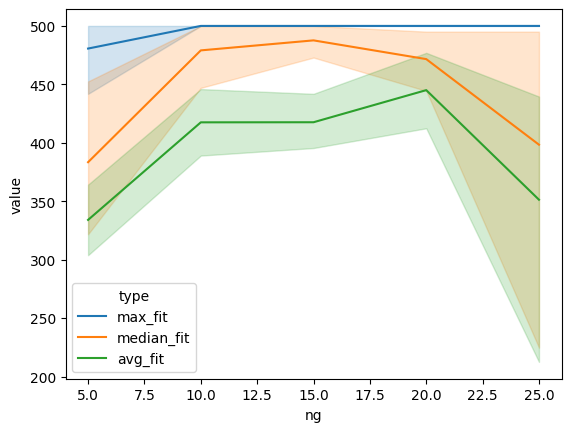

In [172]:
import seaborn as sns
df = df.sort_values("ng")
ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
#ploted_df = ploted_df.groupby("ng").mean().reset_index()
if "seed" in ploted_df.columns:
    ploted_df = ploted_df.drop(columns="seed")
ploted_df = ploted_df.melt(
        id_vars="ng", 
        var_name="type", 
        value_name="value"
    )
sns.lineplot(data=ploted_df, x="ng", y="value", hue="type")

In [169]:
carpole_dict = {
    "sub_novelty":{
        "lambda": 20,
        "diff":40
    },
    "add_novelty":{
        "diff": 50,
        "lambda": 10
    },
    "novelty":{
        "lambda":25,
        "diff": 40
    },
    "fitness":{
        "diff": 10,
        "lambda": 10
    },
    "fit_archiving":{
        "diff": 25,
        "lambda": 15
    },
    "elite_archiving":{
        "lambda": 20,
        "diff": 10
    },
    "novelty_limit":{
        "lambda": 20,
        "diff": 20
    },
    "novelty_archiving":{
        "diff": 20,
        "lambda": 20
    }
}

lunarlander = {
    "fitness": {
        "diff":35
        #research lambda
    },
    "novelty":{
        "diff":60, #research
        "lambda": 25
    },
    "novelty_limit":{
        "lambda": 15, # reasearch & change
        "diff": 20
    },
    "novelty_archiving":{
        "diff": 25,
        "lambda": 50
    },
    "add_novelty":{
        "lambda": 25,
        "diff": 15,
    },
    "sub_novelty":{
        "lambda": 50,
        "diff": 25,
    }
}

In [ ]:
get_decided()

array(['add_novelty.cartpole.diff', 'add_novelty.cartpole.lambda',
       'elite_archiving.lunarlander.diff',
       'elite_archiving.lunarlander.lambda',
       'fit_archiving.cartpole.diff', 'fit_archiving.cartpole.lambda',
       'fit_archiving.lunarlander.diff',
       'fit_archiving.lunarlander.lambda', 'fitness.cartpole.diff',
       'fitness.cartpole.lambda', 'fitness.lunarlander.diff',
       'fitness.lunarlander.lambda', 'novelty.cartpole.diff',
       'novelty.cartpole.lambda', 'novelty.lunarlander.diff',
       'novelty.lunarlander.lambda', 'novelty_archiving.cartpole.diff',
       'novelty_archiving.cartpole.lambda',
       'novelty_archiving.lunarlander.diff',
       'novelty_archiving.lunarlander.lambda',
       'novelty_limit.cartpole.lambda', 'novelty_limit.lunarlander.diff',
       'novelty_limit.lunarlander.lambda', 'sub_novelty.cartpole.diff',
       'sub_novelty.cartpole.lambda'], dtype='<U36')

In [173]:
DECIDED_NG_VALUE = 10   
args = file_content["arguments"]
args["ng"] = DECIDED_NG_VALUE
save_final_hyperparameters(en, cont, alg, args)

<class 'dict'>
Just saved add_novelty,cartpole,lambda
